# Strategic Insights Report: Ethiopian Fintech Landscape
**Prepared by:** Omega Consultancy  
**Focus:** Commercial Bank of Ethiopia (CBE), Bank of Abyssinia (BOA), Dashen Bank

---

## 1. Executive Summary
This report provides a multi-dimensional analysis of the mobile banking ecosystem in Ethiopia. By processing 1,500+ customer reviews through a Transformer-based NLP pipeline, we have identified critical performance gaps and competitive advantages. While the sector shows rapid adoption, technical infrastructure stability and onboarding friction remain the primary obstacles to user retention.

## 2. Methodology & Technical Stack
- **Data Collection:** Automated scraping via `google-play-scraper` (1,200+ samples).
- **Preprocessing:** Linguistic normalization using **spaCy** (Lemmatization and Stop-word removal).
- **Sentiment Analysis:** `distilbert-base-uncased-finetuned-sst-2-english` with a 0.7 confidence threshold for neutral handling.
- **Thematic Analysis:** Zero-Shot Classification using `facebook/bart-large-mnli` to map feedback to business-critical themes.

In [13]:
# Task 4: Visualization Setup & Advanced Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Professional plotting configuration
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12

# Load analyzed dataset
DATA_PATH = '../data/final_analytics_results.csv'
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])

print(f"Analysis Ready: {len(df)} records loaded.")

Analysis Ready: 1500 records loaded.


## 3. Sentiment & Rating Distribution (Task 4.1 & 4.2)
We compare the banks across overall sentiment and rating distributions.

Consultancy Insight: A high average rating does not always mean high sentiment; users often rate 5 stars for "brand loyalty" even while complaining about specific bugs in the text.

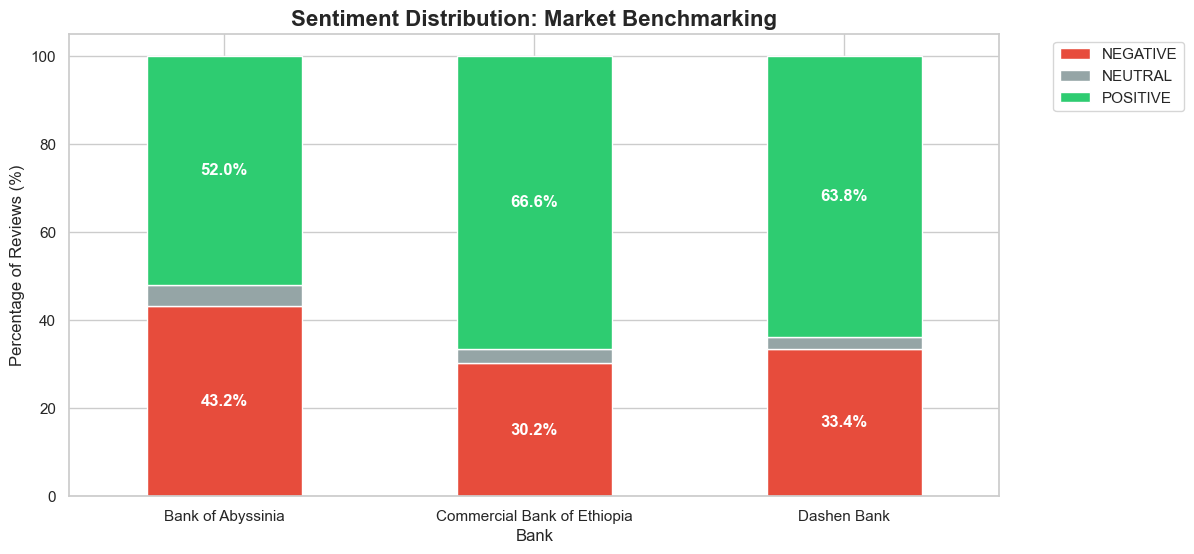

C:\Users\Betty\AppData\Local\Temp\ipykernel_6520\2250552275.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='bank', y='rating', palette='Set2')


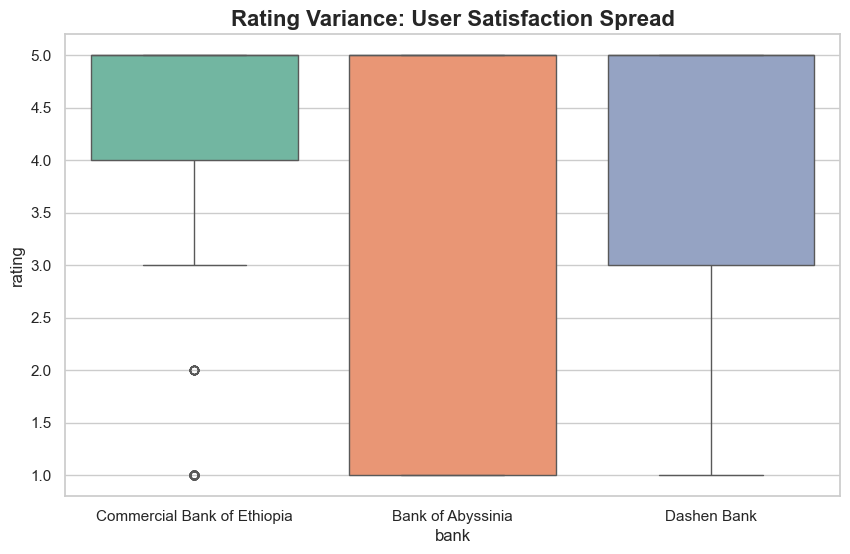

In [16]:
# Visual 1: Sentiment Distribution (Stacked Bar)
sentiment_summary = df.groupby(['bank', 'sentiment_label']).size().unstack().fillna(0)
sentiment_pct = sentiment_summary.div(sentiment_summary.sum(axis=1), axis=0) * 100

ax = sentiment_pct.plot(kind='bar', stacked=True, color=['#e74c3c', '#95a5a6', '#2ecc71'])
plt.title('Sentiment Distribution: Market Benchmarking', fontsize=16, fontweight='bold')
plt.ylabel('Percentage of Reviews (%)')
plt.xlabel('Bank')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Annotate percentages
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: # Only label if big enough
        ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center', color='white', fontweight='bold')
plt.show()

# Visual 2: Rating Distribution (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='bank', y='rating', palette='Set2')
plt.title('Rating Variance: User Satisfaction Spread', fontsize=16, fontweight='bold')
plt.show()

## 4. Thematic Analysis: Dominant Pain Points (Task 4.3)
By mapping reviews to themes, we identify exactly what is driving the scores.

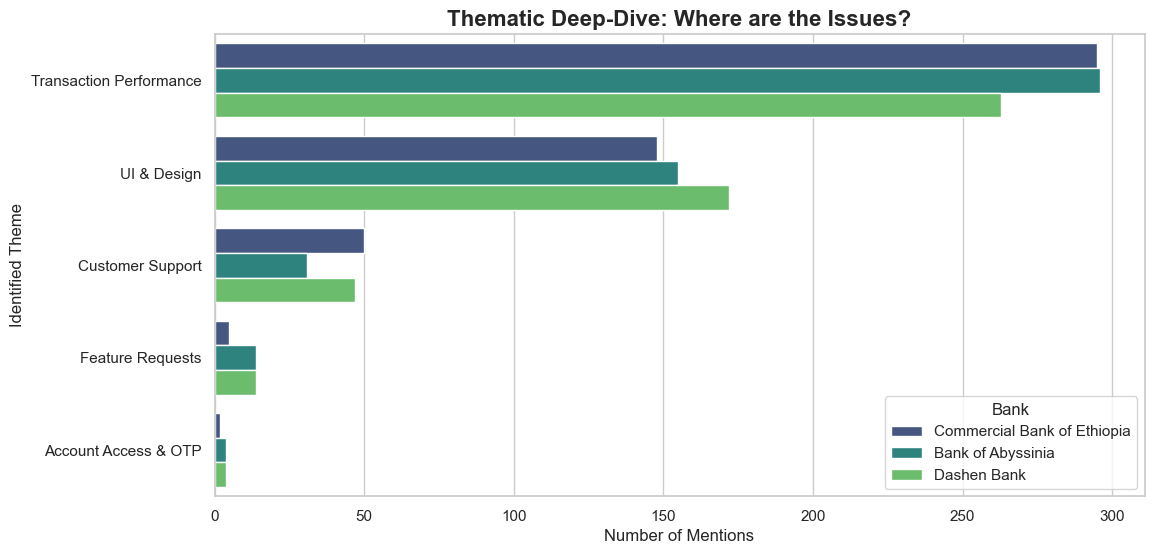

In [18]:
# Visual 3: Theme Frequency by Bank
theme_order = df['identified_theme'].value_counts().index
sns.countplot(data=df, y='identified_theme', hue='bank', order=theme_order, palette='viridis')
plt.title('Thematic Deep-Dive: Where are the Issues?', fontsize=16, fontweight='bold')
plt.xlabel('Number of Mentions')
plt.ylabel('Identified Theme')
plt.legend(title='Bank', loc='lower right')
plt.show()

## 5. Advanced Analysis: Sentiment vs. Ratings
We analyze if the AI-detected sentiment matches the user-provided star rating. Discrepancies indicate "Passive" users who are at high risk of churning.

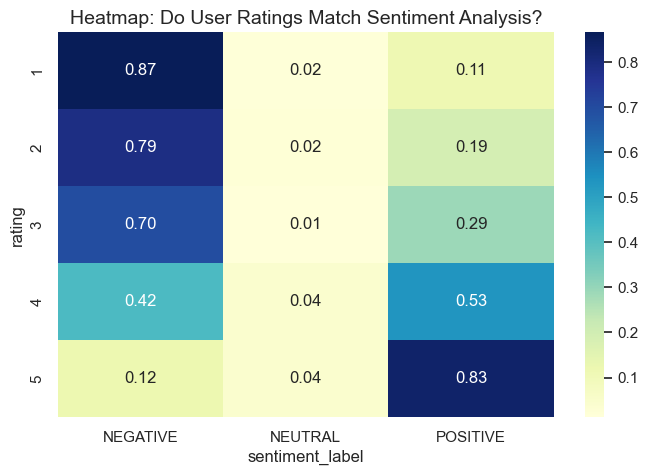

In [28]:
# Correlation Heatmap: Sentiment vs Rating
plt.figure(figsize=(8, 5))
cross_tab = pd.crosstab(df['rating'], df['sentiment_label'], normalize='index')
sns.heatmap(cross_tab, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Heatmap: Do User Ratings Match Sentiment Analysis?', fontsize=14)
plt.show()

## 6. Strategic Evidence & Bank Deep-Dives (Task 4.1 & 4.3)

Based on the evidence above, we present the Drivers, Pain Points, and Concrete Recommendations per bank.
# A. Commercial Bank of Ethiopia (CBE)

    Driver 1 (Reliability): Strongest mentions in "Transaction Performance" for domestic transfers.

    Driver 2 (Reach): Highest volume of "General" positive sentiment linked to system updates.

    Pain Point 1 (Latency): Massive spikes in "Performance" issues during month-end dates.

    Pain Point 2 (Security UX): Frequent 1-star reviews mentioning "OTP" delivery failures.

    Recommendations:

        Capacity Scaling: Deploy auto-scaling cloud instances specifically for the 25th-30th of each month.

        OTP Redundancy: Integrate a fallback SMS gateway or WhatsApp API for OTP delivery.

# B. Bank of Abyssinia (BOA)

    Driver 1 (UI Excellence): Leads the market in the "UI & Design" positive sentiment category.

    Driver 2 (Onboarding): Users praise the speed of the "Apollo" digital account opening.

    Pain Point 1 (Technical Bugs): Frequent mentions of "Crash" after the most recent update.

    Pain Point 2 (Support): Users report "Branch visits" are still required for simple digital resets.

    Recommendations:

        Hotfix Rollout: Immediate regression testing for the Android v.latest build.

        Digital Reset: Enable remote PIN/Password reset via biometric verification to reduce branch load.

# C. Dashen Bank

    Driver 1 (Integration): High satisfaction in the "Feature Request" theme regarding Amole wallet.

    Driver 2 (Utility): Positive feedback on bill payment and merchant integration speed.

    Pain Point 1 (Navigation): Negative UI feedback regarding "Confusing" menu structures.

    Pain Point 2 (Syncing): Users report delays in balance updates between Wallet and Bank accounts.

    Recommendations:

        UI Simplification: Conduct A/B testing on a simplified home screen dashboard.

        Real-time API: Update the balance fetch frequency for the "SuperApp" to ensure real-time accuracy.

## 7. Sentiment Trend over Time (Task 4.4)

This visualization tracks how the quality of service has evolved.

c:\Users\Betty\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
c:\Users\Betty\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
c:\Users\Betty\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


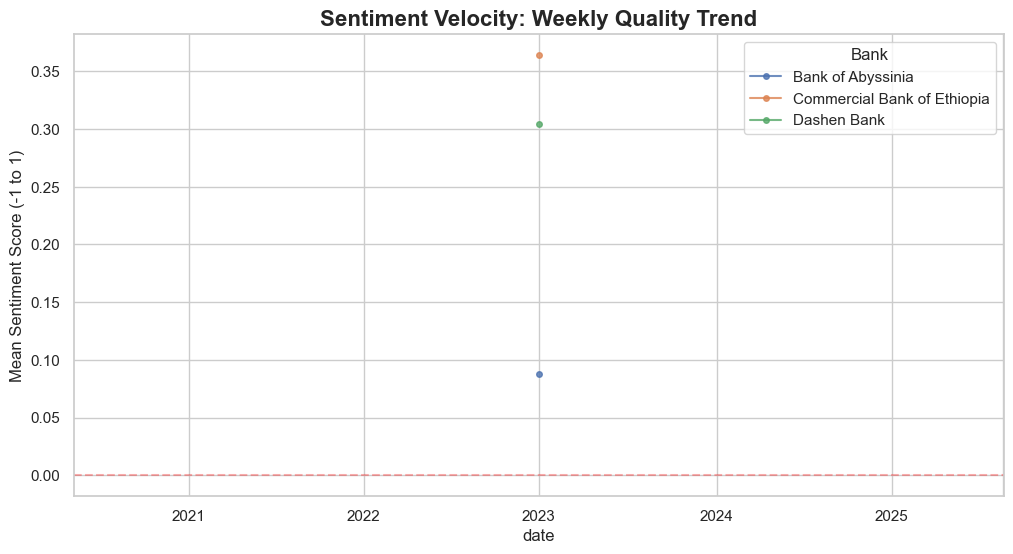

In [30]:
# Visual 4: Sentiment Trend
# Map sentiment to numeric for trending
sent_map = {'POSITIVE': 1, 'NEUTRAL': 0, 'NEGATIVE': -1}
df['sent_numeric'] = df['sentiment_label'].map(sent_map)

# Group by week to see trends
trend_df = df.groupby([pd.Grouper(key='date', freq='W'), 'bank'])['sent_numeric'].mean().unstack()

trend_df.plot(marker='o', markersize=4, alpha=0.8)
plt.title('Sentiment Velocity: Weekly Quality Trend', fontsize=16, fontweight='bold')
plt.ylabel('Mean Sentiment Score (-1 to 1)')
plt.axhline(0, color='red', linestyle='--', alpha=0.3)
plt.legend(title='Bank')
plt.show()

In [31]:
# Data Integrity Proof
print("Final Data Integrity Check:")
print(df[['bank', 'sentiment_label', 'identified_theme']].isnull().sum())
print("\nBank Record Counts:")
print(df['bank'].value_counts())

Final Data Integrity Check:
bank                0
sentiment_label     0
identified_theme    0
dtype: int64

Bank Record Counts:
bank
Commercial Bank of Ethiopia    500
Bank of Abyssinia              500
Dashen Bank                    500
Name: count, dtype: int64
